In [ ]:
d = {1: 45, 2: 33, 3: 56, 4: 99, }

In [6]:
import numpy as np
import collections
Acq = collections.namedtuple('Acq', ['angle', 'image'])
lst = [Acq(angle, np.zeros((4,4))) for angle in range(30)]
lst.sort()
lst

[Acq(angle=0, image=array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])),
 Acq(angle=1, image=array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])),
 Acq(angle=2, image=array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])),
 Acq(angle=3, image=array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])),
 Acq(angle=4, image=array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])),
 Acq(angle=5, image=array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])),
 Acq(angle=6, image=array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])),
 Acq(angle=7, image=array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 

In [ ]:
Projection = collections.namedtuple('values','angle')

In [4]:
t = tuple((a,b) for a in range(3) for b in range (3))
t

((0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2))

In [5]:
l1 = [1,2,3,4,5,6,7,8,9]
l2 = ['uno', 'dos', 'tres', 'cuatro', 'cinco', 'seis', 'siete', 'ocho', 'nueve']
t = tuple((a,b) for a, b in zip(l1, l2))
t

((1, 'uno'),
 (2, 'dos'),
 (3, 'tres'),
 (4, 'cuatro'),
 (5, 'cinco'),
 (6, 'seis'),
 (7, 'siete'),
 (8, 'ocho'),
 (9, 'nueve'))

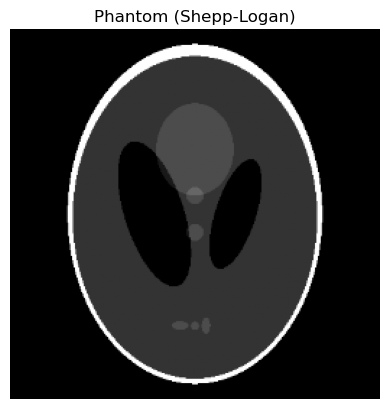

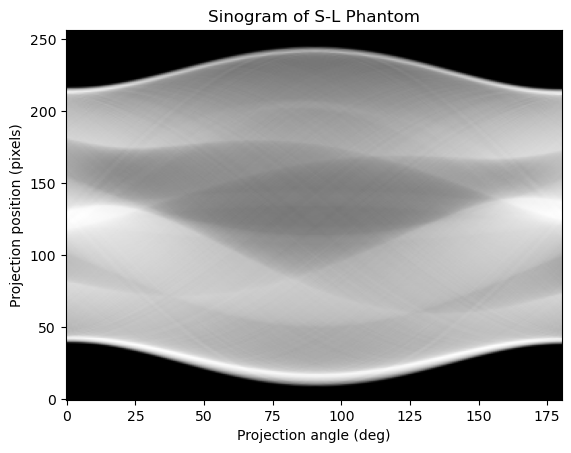

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize

phantom = shepp_logan_phantom()
phantom = resize(phantom, (256, 256), mode='reflect', anti_aliasing=True)

plt.imshow(phantom, cmap='gray')
plt.title("Phantom (Shepp-Logan)")
plt.axis('off')
plt.show()

from skimage.transform import radon

max_angle=180.0
theta =  np.linspace(0., max_angle, max(phantom.shape), endpoint=False) # (start, stop, n_samples, don't include endpoint)
sinogram = radon(phantom, theta=theta, circle=True)
dx, dy = 0.5*max_angle/max(phantom.shape), 0.5

plt.imshow(sinogram, cmap=plt.cm.Greys_r, extent=(-dx, max_angle+dx, -dy, sinogram.shape[0]+dy) ,aspect='auto')
plt.title("Sinogram of S-L Phantom")
plt.xlabel("Projection angle (deg)")
plt.ylabel("Projection position (pixels)")
plt.show()

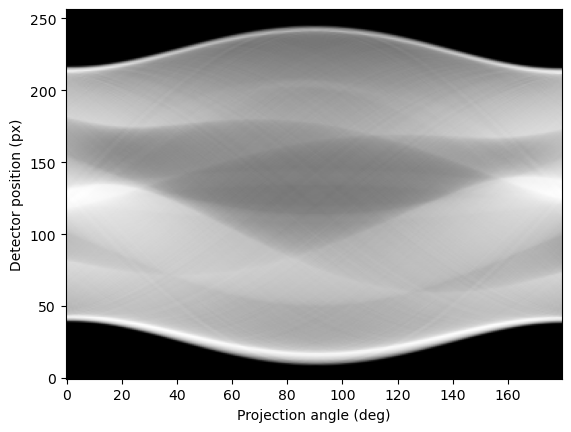

179.296875


Projection(values=array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.25012734e-02,
       3.51075652e+00, 2.69048642e+01, 4.40401814e+01, 5.64336904e+01,
       5.66119964e+01, 4.56351971e+01, 4.26439957e+01, 4.07938974e+01,
       4.01454816e+01, 4.02238341e+01, 4.03201599e+01, 4.00850488e+01,
       4.00819696e+01, 4.04933315e+01, 4.08223845e+01, 4.13

In [2]:
import sys
sys.path.append('..')

from recon import Sinogram

sino = Sinogram(data=sinogram, angles=theta)
sino.plot()
print(sino[-1].angle)
sino[-1]